# Data Exploration: Brexit Frame Classification

This notebook explores the `training_data_praesentation.csv` file to understand:
- Dataset structure and train/test/validation splits
- Frame label distributions and inconsistencies
- Text length statistics
- Content patterns
- Baseline metrics


In [1]:
# DuckDB no longer needed - using CSV files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)


## 1. Load Data from CSV


In [2]:
# Load data from training_data_praesentation.csv
# Use keep_default_na=False to prevent pandas from converting "None" string to NaN
# Then convert empty strings to NaN if needed
df = pd.read_csv('training_data_praesentation.csv', keep_default_na=False)

# Convert empty strings to NaN (actual missing values)
if 'frame_label' in df.columns:
    df['frame_label'] = df['frame_label'].replace('', np.nan)
    # Also handle any other common missing value representations
    df['frame_label'] = df['frame_label'].replace(['nan', 'NaN', 'null', 'NULL'], np.nan)

print("⚠️  NOTE: 'None' is treated as a valid frame label, not as null/NaN")

print("="*80)
print("INITIAL DATA LOAD")
print("="*80)
print(f"Total samples: {len(df):,}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nDataset info:")
df.info()

# Verify that "None" is treated as a valid label, not as null
if 'frame_label' in df.columns:
    none_as_string = (df['frame_label'] == 'None').sum()
    none_as_null = df['frame_label'].isna().sum()
    print(f"\n✅ Verification:")
    print(f"   - 'None' as string (valid label): {none_as_string} samples")
    print(f"   - Actual null/NaN values: {none_as_null} samples")
    if none_as_string > 0 and none_as_null == 0:
        print(f"   ✅ 'None' is correctly treated as a valid frame label")
    elif none_as_string == 0 and none_as_null > 0:
        print(f"   ⚠️  'None' was converted to NaN - this should not happen")

print("\n" + "="*80)
print("CHECKING DATASET SPLIT")
print("="*80)
if 'dataset_split' in df.columns:
    print("\nDataset split distribution:")
    print(df['dataset_split'].value_counts())
    unique_splits = df['dataset_split'].unique()
    print(f"\nUnique splits found: {list(unique_splits)}")
    
    # Check if validation split exists
    if 'validation' not in unique_splits:
        print("\n⚠️  WARNING: No validation split found!")
        print("   Creating validation split from training data...")
        
        # Create validation split from training data
        from sklearn.model_selection import train_test_split
        
        # Get training data
        train_data = df[df['dataset_split'] == 'train'].copy()
        test_data = df[df['dataset_split'] == 'test'].copy()
        
        # Split training data into train and validation (80/20 split)
        # Stratify by frame_label if available
        if train_data['frame_label'].notna().sum() > 0:
            train_data_labeled = train_data[train_data['frame_label'].notna()].copy()
            train_data_unlabeled = train_data[train_data['frame_label'].isna()].copy()
            
            # Split labeled data
            train_new, val_new = train_test_split(
                train_data_labeled,
                test_size=0.2,
                random_state=42,
                stratify=train_data_labeled['frame_label']
            )
            
            # Add unlabeled data proportionally (only if there are unlabeled samples)
            if len(train_data_unlabeled) > 0:
                train_unlabeled, val_unlabeled = train_test_split(
                    train_data_unlabeled,
                    test_size=0.2,
                    random_state=42
                )
                train_new = pd.concat([train_new, train_unlabeled], ignore_index=True)
                val_new = pd.concat([val_new, val_unlabeled], ignore_index=True)
            else:
                # No unlabeled data, just use the labeled splits
                print(f"   ℹ️  No unlabeled samples in training data")
        else:
            # No labels available, just random split
            train_new, val_new = train_test_split(
                train_data,
                test_size=0.2,
                random_state=42
            )
        
        # Update splits
        train_new['dataset_split'] = 'train'
        val_new['dataset_split'] = 'validation'
        test_data['dataset_split'] = 'test'
        
        # Combine all data
        df = pd.concat([train_new, val_new, test_data], ignore_index=True)
        
        print(f"\n✅ Created validation split:")
        print(f"   - Training: {len(train_new):,} samples")
        print(f"   - Validation: {len(val_new):,} samples")
        print(f"   - Test: {len(test_data):,} samples")
    else:
        print("\n✅ Validation split already exists")
else:
    print("\n⚠️  WARNING: No dataset_split column found!")
    print("   Creating train/test/validation split...")
    
    from sklearn.model_selection import train_test_split
    
    # First split: train+val vs test (80/20)
    train_val, test_data = train_test_split(
        df,
        test_size=0.2,
        random_state=42,
        stratify=df['frame_label'] if df['frame_label'].notna().sum() > 0 else None
    )
    
    # Second split: train vs val (80/20 of train_val, so 64/16 of total)
    train_data, val_data = train_test_split(
        train_val,
        test_size=0.2,
        random_state=42,
        stratify=train_val['frame_label'] if train_val['frame_label'].notna().sum() > 0 else None
    )
    
    # Add split labels
    train_data['dataset_split'] = 'train'
    val_data['dataset_split'] = 'validation'
    test_data['dataset_split'] = 'test'
    
    # Combine all data
    df = pd.concat([train_data, val_data, test_data], ignore_index=True)
    
    print(f"\n✅ Created dataset splits:")
    print(f"   - Training: {len(train_data):,} samples ({len(train_data)/len(df)*100:.1f}%)")
    print(f"   - Validation: {len(val_data):,} samples ({len(val_data)/len(df)*100:.1f}%)")
    print(f"   - Test: {len(test_data):,} samples ({len(test_data)/len(df)*100:.1f}%)")

print("\n" + "="*80)
print("FINAL DATASET INFO")
print("="*80)
print(f"Total samples: {len(df):,}")
print(f"\nFinal split distribution:")
print(df['dataset_split'].value_counts())
print(f"\nDataset info:")
df.info()


⚠️  NOTE: 'None' is treated as a valid frame label, not as null/NaN
INITIAL DATA LOAD
Total samples: 2,000

Columns: ['chunk_id', 'chunk_text', 'dataset_split', 'frame_label', 'Annotation']

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   chunk_id       2000 non-null   object
 1   chunk_text     2000 non-null   object
 2   dataset_split  2000 non-null   object
 3   frame_label    2000 non-null   object
 4   Annotation     2000 non-null   object
dtypes: object(5)
memory usage: 78.3+ KB

✅ Verification:
   - 'None' as string (valid label): 305 samples
   - Actual null/NaN values: 0 samples
   ✅ 'None' is correctly treated as a valid frame label

CHECKING DATASET SPLIT

Dataset split distribution:
dataset_split
train    1700
test      300
Name: count, dtype: int64

Unique splits found: ['train', 'test']

⚠️  WARNING: No validati

In [3]:
# Display first few samples
print("First 10 samples:")
df.head(10)


First 10 samples:


,chunk_id,chunk_text,dataset_split,frame_label,Annotation
0,chunk_271152,I begin by congratulating my hon. Friend on hi...,train,Economic,händisch
1,chunk_010944,arrest on behalf of the USA under legal condit...,train,Economic,händisch
2,chunk_161470,(a) the fiscal and economic effects of the exe...,train,None,händisch
3,chunk_270306,Closely tied up with the whole question of fix...,train,Moral Value,händisch
4,chunk_160092,I very much welcome the Secretary of State’s c...,train,Human Impact,händisch
5,chunk_292078,Indeed. I think my hon. Friend has confirmed t...,train,Powerlessness,händisch
6,chunk_060931,My hon. Friend is absolutely right. One reason...,train,Economic,händisch
7,chunk_251261,I once again associate myself with the remarks...,train,Conflict,händisch
8,chunk_282267,I happened to know many people who worked at t...,train,Economic,händisch
9,chunk_221592,What discussions he has had with the Secretary...,train,Human Impact,händisch


## 2. Frame Label Inconsistency Check

Before analyzing distributions, let's check for inconsistencies in frame labels.


In [4]:
# Check for inconsistencies in frame labels
print("="*80)
print("FRAME LABEL INCONSISTENCY CHECK")
print("="*80)
print("ℹ️  NOTE: 'None' is a valid frame label (not null/NaN)")

# 1. Check for null values (actual missing values, not "None" label)
null_count = df['frame_label'].isna().sum()
print(f"\n1. NULL VALUES (actual missing labels):")
print(f"   - Count: {null_count} ({null_count/len(df)*100:.2f}%)")
if null_count > 0:
    print(f"   ⚠️  WARNING: {null_count} samples have missing frame labels")
    print(f"   - These samples are in splits: {df[df['frame_label'].isna()]['dataset_split'].value_counts().to_dict()}")
else:
    print(f"   ✅ No missing frame labels")

# Check for "None" as a valid label
none_count = (df['frame_label'] == 'None').sum()
if none_count > 0:
    print(f"\n   ℹ️  'None' frame label: {none_count} samples (this is a valid label, not null)")

# 2. Check for case inconsistencies
if df['frame_label'].notna().sum() > 0:
    unique_labels = df['frame_label'].dropna().unique()
    print(f"\n2. UNIQUE FRAME LABELS ({len(unique_labels)} found):")
    for label in sorted(unique_labels):
        count = (df['frame_label'] == label).sum()
        label_type = " (valid label)" if label == 'None' else ""
        print(f"   - '{label}': {count} samples{label_type}")
    
    # Check for case variations
    labels_lower = [str(label).lower() for label in unique_labels]
    if len(labels_lower) != len(set(labels_lower)):
        print(f"\n   ⚠️  WARNING: Potential case inconsistencies detected!")
        from collections import Counter
        case_counts = Counter(labels_lower)
        duplicates = {k: v for k, v in case_counts.items() if v > 1}
        print(f"   - Case-insensitive duplicates: {duplicates}")
    else:
        print(f"   ✅ No case inconsistencies detected")

# 3. Check for whitespace issues
if df['frame_label'].notna().sum() > 0:
    labels_with_whitespace = df['frame_label'].dropna().apply(lambda x: str(x) != str(x).strip())
    whitespace_count = labels_with_whitespace.sum()
    print(f"\n3. WHITESPACE ISSUES:")
    if whitespace_count > 0:
        print(f"   ⚠️  WARNING: {whitespace_count} labels have leading/trailing whitespace")
        print(f"   - Examples: {df[df['frame_label'].notna()][labels_with_whitespace]['frame_label'].head().tolist()}")
        # Clean whitespace
        df['frame_label'] = df['frame_label'].apply(lambda x: str(x).strip() if pd.notna(x) else x)
        print(f"   ✅ Cleaned whitespace")
    else:
        print(f"   ✅ No whitespace issues detected")

# 4. Check for duplicate chunk_ids with different labels
if 'chunk_id' in df.columns:
    print(f"\n4. DUPLICATE CHUNK IDS:")
    duplicates = df[df.duplicated(subset=['chunk_id'], keep=False)]
    if len(duplicates) > 0:
        print(f"   ⚠️  WARNING: {len(duplicates)} rows have duplicate chunk_ids")
        # Check if duplicates have different labels
        dup_with_diff_labels = duplicates.groupby('chunk_id')['frame_label'].nunique()
        conflicting = dup_with_diff_labels[dup_with_diff_labels > 1]
        if len(conflicting) > 0:
            print(f"   ⚠️  CRITICAL: {len(conflicting)} chunk_ids have conflicting frame labels!")
            print(f"   - Examples:")
            for chunk_id in conflicting.head(5).index:
                print(f"     * {chunk_id}: {duplicates[duplicates['chunk_id']==chunk_id][['chunk_id', 'frame_label']].values.tolist()}")
        else:
            print(f"   ✅ Duplicate chunk_ids have consistent labels")
    else:
        print(f"   ✅ No duplicate chunk_ids detected")

# 5. Overall distribution
print(f"\n5. OVERALL FRAME DISTRIBUTION:")
if df['frame_label'].notna().sum() > 0:
    print(df['frame_label'].value_counts(dropna=False))
else:
    print("   ⚠️  No frame labels available!")


FRAME LABEL INCONSISTENCY CHECK
ℹ️  NOTE: 'None' is a valid frame label (not null/NaN)

1. NULL VALUES (actual missing labels):
   - Count: 0 (0.00%)
   ✅ No missing frame labels

   ℹ️  'None' frame label: 305 samples (this is a valid label, not null)

2. UNIQUE FRAME LABELS (6 found):
   - 'Conflict': 439 samples
   - 'Economic': 457 samples
   - 'Human Impact': 234 samples
   - 'Moral Value': 248 samples
   - 'None': 305 samples (valid label)
   - 'Powerlessness': 317 samples
   ✅ No case inconsistencies detected

3. WHITESPACE ISSUES:
   ✅ No whitespace issues detected

4. DUPLICATE CHUNK IDS:
   ✅ No duplicate chunk_ids detected

5. OVERALL FRAME DISTRIBUTION:
frame_label
Economic         457
Conflict         439
Powerlessness    317
None             305
Moral Value      248
Human Impact     234
Name: count, dtype: int64


In [5]:
# Distribution by split
print("\n" + "="*80)
print("FRAME DISTRIBUTION BY SPLIT")
print("="*80)
if df['frame_label'].notna().sum() > 0:
    split_dist = pd.crosstab(df['frame_label'], df['dataset_split'], margins=True)
    print("\nFrame Distribution by Split:")
    print(split_dist)
    
    # Check for class imbalance in each split
    print("\n" + "-"*80)
    print("CLASS BALANCE CHECK BY SPLIT:")
    for split in df['dataset_split'].unique():
        split_data = df[df['dataset_split'] == split]
        labeled_data = split_data[split_data['frame_label'].notna()]
        if len(labeled_data) > 0:
            label_counts = labeled_data['frame_label'].value_counts()
            min_count = label_counts.min()
            max_count = label_counts.max()
            imbalance_ratio = max_count / min_count if min_count > 0 else float('inf')
            print(f"\n{split.upper()}:")
            print(f"   - Total samples: {len(split_data):,}")
            print(f"   - Labeled samples: {len(labeled_data):,}")
            print(f"   - Unlabeled samples: {len(split_data) - len(labeled_data):,}")
            if len(label_counts) > 0:
                print(f"   - Classes: {len(label_counts)}")
                print(f"   - Min count: {min_count}, Max count: {max_count}")
                print(f"   - Imbalance ratio: {imbalance_ratio:.2f}x")
                if imbalance_ratio > 2.0:
                    print(f"   ⚠️  WARNING: Significant class imbalance detected!")
                else:
                    print(f"   ✅ Classes are relatively balanced")
else:
    print("\n⚠️  No frame labels available for distribution analysis")



FRAME DISTRIBUTION BY SPLIT

Frame Distribution by Split:
dataset_split  test  train  validation   All
frame_label                                 
Conflict         62    302          75   439
Economic         82    300          75   457
Human Impact     22    169          43   234
Moral Value      59    151          38   248
None             38    214          53   305
Powerlessness    37    224          56   317
All             300   1360         340  2000

--------------------------------------------------------------------------------
CLASS BALANCE CHECK BY SPLIT:

TRAIN:
   - Total samples: 1,360
   - Labeled samples: 1,360
   - Unlabeled samples: 0
   - Classes: 6
   - Min count: 151, Max count: 302
   - Imbalance ratio: 2.00x
   ✅ Classes are relatively balanced

VALIDATION:
   - Total samples: 340
   - Labeled samples: 340
   - Unlabeled samples: 0
   - Classes: 6
   - Min count: 38, Max count: 75
   - Imbalance ratio: 1.97x
   ✅ Classes are relatively balanced

TEST:
   - Tot

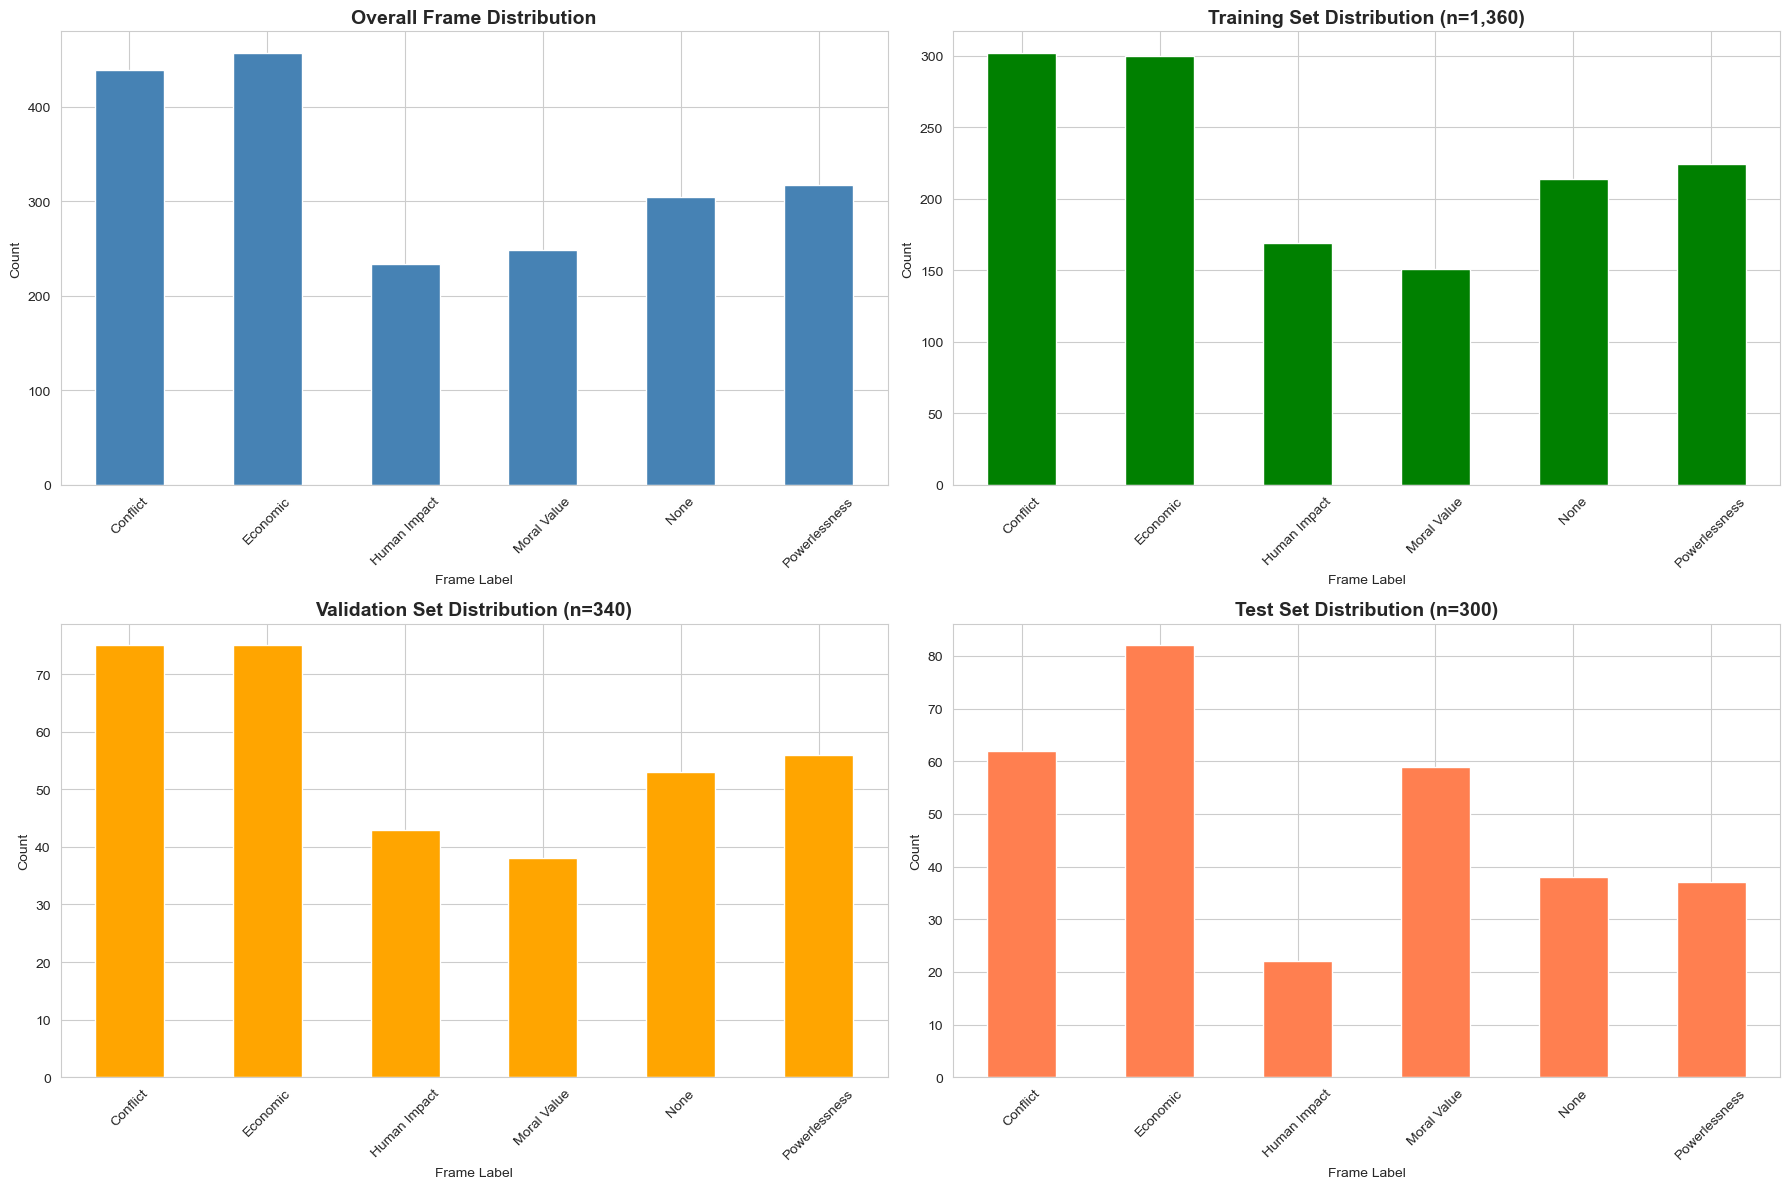


✅ Frame distribution plots saved to results/frame_distribution.png


In [6]:
# Visualize distribution
if df['frame_label'].notna().sum() > 0:
    # Create results directory if it doesn't exist
    import os
    os.makedirs('results', exist_ok=True)
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    
    # Overall distribution
    df['frame_label'].value_counts().sort_index().plot(kind='bar', ax=axes[0, 0], color='steelblue')
    axes[0, 0].set_title('Overall Frame Distribution', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Frame Label')
    axes[0, 0].set_ylabel('Count')
    axes[0, 0].tick_params(axis='x', rotation=45)
    
    # Train distribution
    train_df = df[df['dataset_split'] == 'train']
    if len(train_df[train_df['frame_label'].notna()]) > 0:
        train_df['frame_label'].value_counts().sort_index().plot(kind='bar', ax=axes[0, 1], color='green')
        axes[0, 1].set_title(f'Training Set Distribution (n={len(train_df):,})', fontsize=14, fontweight='bold')
        axes[0, 1].set_xlabel('Frame Label')
        axes[0, 1].set_ylabel('Count')
        axes[0, 1].tick_params(axis='x', rotation=45)
    
    # Validation distribution
    val_df = df[df['dataset_split'] == 'validation']
    if len(val_df[val_df['frame_label'].notna()]) > 0:
        val_df['frame_label'].value_counts().sort_index().plot(kind='bar', ax=axes[1, 0], color='orange')
        axes[1, 0].set_title(f'Validation Set Distribution (n={len(val_df):,})', fontsize=14, fontweight='bold')
        axes[1, 0].set_xlabel('Frame Label')
        axes[1, 0].set_ylabel('Count')
        axes[1, 0].tick_params(axis='x', rotation=45)
    
    # Test distribution
    test_df = df[df['dataset_split'] == 'test']
    if len(test_df[test_df['frame_label'].notna()]) > 0:
        test_df['frame_label'].value_counts().sort_index().plot(kind='bar', ax=axes[1, 1], color='coral')
        axes[1, 1].set_title(f'Test Set Distribution (n={len(test_df):,})', fontsize=14, fontweight='bold')
        axes[1, 1].set_xlabel('Frame Label')
        axes[1, 1].set_ylabel('Count')
        axes[1, 1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.savefig('results/frame_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✅ Frame distribution plots saved to results/frame_distribution.png")
else:
    print("\n⚠️  Cannot create distribution plots: No frame labels available")


## 3. Text Length Analysis


In [7]:
# Calculate text statistics
df['text_length'] = df['chunk_text'].str.len()
df['word_count'] = df['chunk_text'].str.split().str.len()

print("Text Length Statistics (characters):")
print(df['text_length'].describe())
print("\nWord Count Statistics:")
print(df['word_count'].describe())


Text Length Statistics (characters):
count    2000.000000
mean      763.214000
std       313.351181
min        34.000000
25%       510.000000
50%       766.000000
75%      1030.000000
max      1298.000000
Name: text_length, dtype: float64

Word Count Statistics:
count    2000.000000
mean      132.531000
std        54.176559
min         8.000000
25%        88.750000
50%       134.000000
75%       178.000000
max       245.000000
Name: word_count, dtype: float64


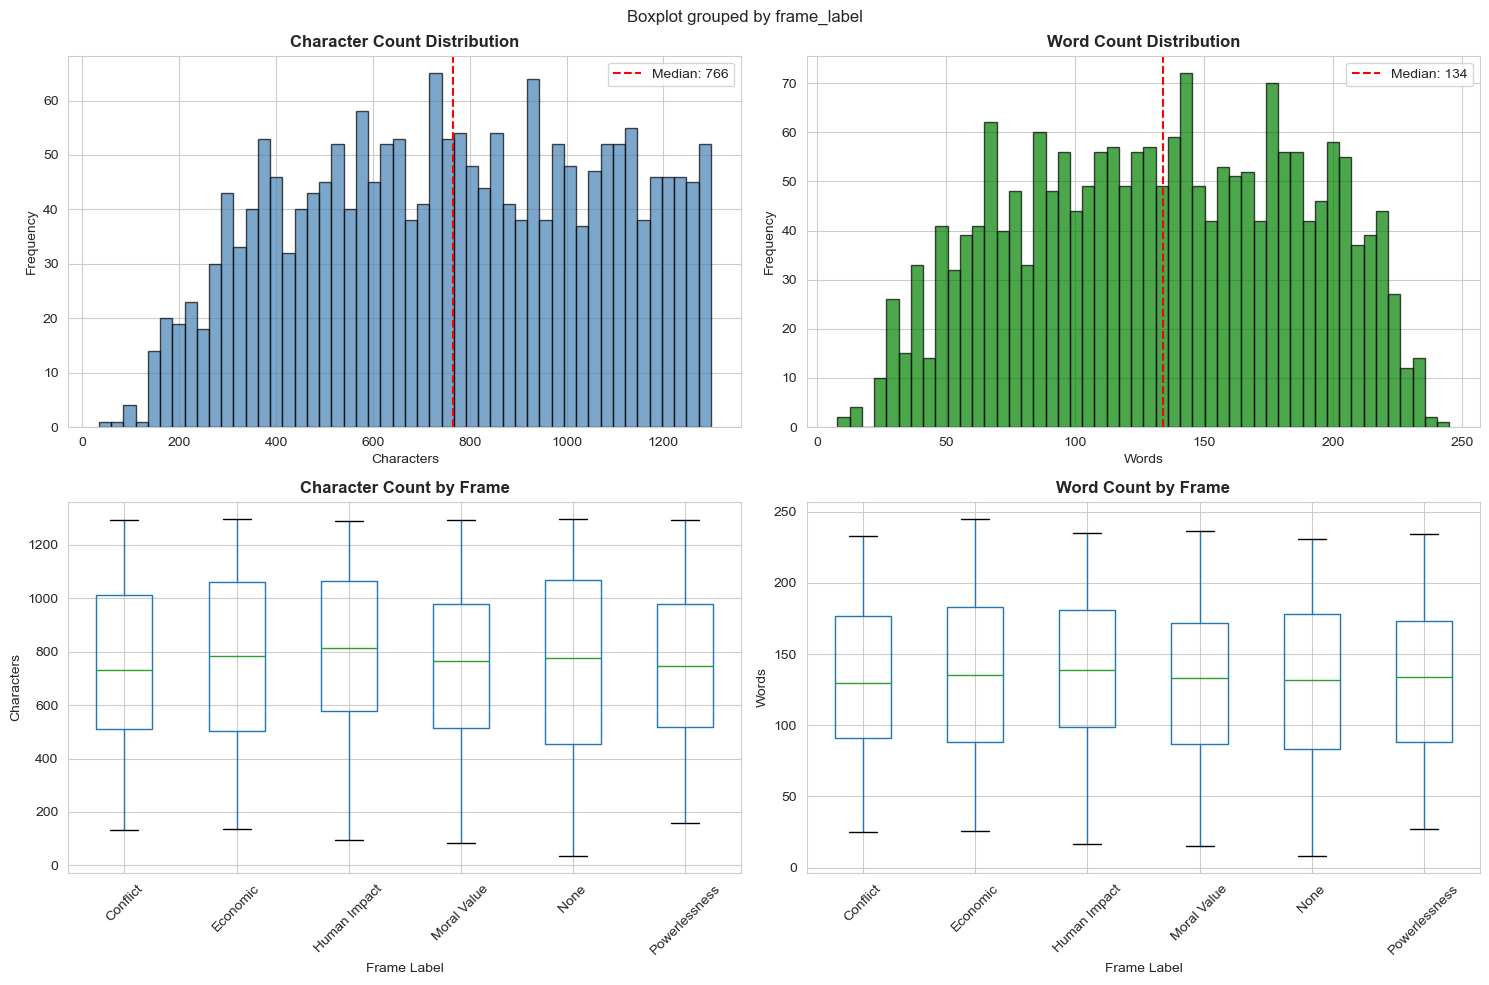

In [8]:
# Visualize text length distributions
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Character count distribution
axes[0, 0].hist(df['text_length'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Character Count Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Characters')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(df['text_length'].median(), color='red', linestyle='--', label=f'Median: {df["text_length"].median():.0f}')
axes[0, 0].legend()

# Word count distribution
axes[0, 1].hist(df['word_count'], bins=50, color='green', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Word Count Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Words')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(df['word_count'].median(), color='red', linestyle='--', label=f'Median: {df["word_count"].median():.0f}')
axes[0, 1].legend()

# Box plot by frame label (character count)
df.boxplot(column='text_length', by='frame_label', ax=axes[1, 0])
axes[1, 0].set_title('Character Count by Frame', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Frame Label')
axes[1, 0].set_ylabel('Characters')
axes[1, 0].tick_params(axis='x', rotation=45)
plt.sca(axes[1, 0])
plt.xticks(rotation=45)

# Box plot by frame label (word count)
df.boxplot(column='word_count', by='frame_label', ax=axes[1, 1])
axes[1, 1].set_title('Word Count by Frame', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Frame Label')
axes[1, 1].set_ylabel('Words')
axes[1, 1].tick_params(axis='x', rotation=45)
plt.sca(axes[1, 1])
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('results/text_length_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


In [9]:
# Statistics by frame label
if df['frame_label'].notna().sum() > 0 and 'word_count' in df.columns:
    print("\nWord Count Statistics by Frame Label:")
    frame_stats = df[df['frame_label'].notna()].groupby('frame_label')['word_count'].describe()
    print(frame_stats)
else:
    print("\n⚠️  Cannot compute statistics: Missing frame labels or word_count column")



Word Count Statistics by Frame Label:
               count        mean        std   min   25%    50%     75%    max
frame_label                                                                  
Conflict       439.0  133.063781  52.884086  25.0  91.0  130.0  177.00  233.0
Economic       457.0  134.026258  55.684057  26.0  88.0  135.0  183.00  245.0
Human Impact   234.0  138.299145  53.182698  17.0  99.0  138.5  180.75  235.0
Moral Value    248.0  130.875000  51.609132  15.0  87.0  133.5  171.50  236.0
None           305.0  129.186885  58.833629   8.0  83.0  132.0  178.00  231.0
Powerlessness  317.0  129.892744  51.679892  27.0  88.0  134.0  173.00  234.0


## 4. Sample Texts from Each Frame


In [10]:
# Display sample texts from each frame category
if df['frame_label'].notna().sum() > 0:
    for frame in sorted(df['frame_label'].dropna().unique()):
        print(f"\n{'='*80}")
        print(f"FRAME: {frame}")
        print(f"{'='*80}")
        frame_data = df[df['frame_label'] == frame]
        if len(frame_data) > 0:
            samples = frame_data.sample(min(3, len(frame_data)))
            for idx, (i, row) in enumerate(samples.iterrows(), 1):
                print(f"\nSample {idx}:")
                print(f"Chunk ID: {row['chunk_id']}")
                if 'word_count' in df.columns:
                    print(f"Word Count: {row['word_count']}")
                print(f"Text: {row['chunk_text'][:500]}..." if len(row['chunk_text']) > 500 else f"Text: {row['chunk_text']}")
                print("-" * 80)
else:
    print("\n⚠️  Cannot display samples: No frame labels available")



FRAME: Conflict

Sample 1:
Chunk ID: chunk_011003
Word Count: 177
Text: It is always important to remember how we reached the position we are in. My hon. Friend the Member for Stone (Sir William Cash) and my right hon. Friend the Member for Wokingham (Mr Redwood) reminded us that, prior to the Lisbon treaty, these matters were all outside the jurisdiction of the European Court of Justice. They used to be intergovernmental matters. Of course, it was the previous Labour Government who took the decision to put us in the position we are in now. They sold us down this ri...
--------------------------------------------------------------------------------

Sample 2:
Chunk ID: chunk_302564
Word Count: 85
Text: A consequence of Brexit was always that we needed to erect a trade border between Britain and the EU, and there are only two places where that could go—either in the Irish sea, or a land border on the island of Ireland. As the Government are now trying to reverse the agreement that puts

## 5. Tokenization Length Analysis (for BART)


In [11]:
# Estimate token counts (rough approximation: words * 1.3)
df['estimated_tokens'] = (df['word_count'] * 1.3).astype(int)

print("Estimated Token Count Statistics:")
print(df['estimated_tokens'].describe())
print(f"\nTexts > 512 tokens: {(df['estimated_tokens'] > 512).sum()} ({(df['estimated_tokens'] > 512).mean()*100:.2f}%)")
print(f"Texts > 1024 tokens: {(df['estimated_tokens'] > 1024).sum()} ({(df['estimated_tokens'] > 1024).mean()*100:.2f}%)")

# Recommend max_length
percentile_95 = df['estimated_tokens'].quantile(0.95)
print(f"\n95th percentile: {percentile_95:.0f} tokens")
if percentile_95 <= 512:
    print("✅ Recommendation: Use max_length=512")
elif percentile_95 <= 1024:
    print("✅ Recommendation: Use max_length=1024")
else:
    print("⚠️ Recommendation: Use max_length=1024 with truncation")


Estimated Token Count Statistics:
count    2000.000000
mean      171.847500
std        70.427319
min        10.000000
25%       114.750000
50%       174.000000
75%       231.000000
max       318.000000
Name: estimated_tokens, dtype: float64

Texts > 512 tokens: 0 (0.00%)
Texts > 1024 tokens: 0 (0.00%)

95th percentile: 280 tokens
✅ Recommendation: Use max_length=512


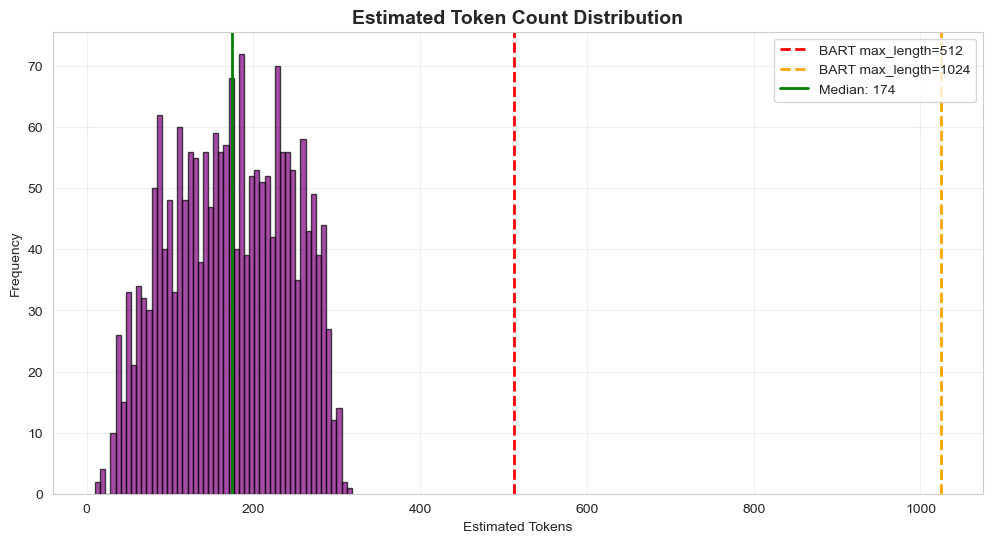

In [12]:
# Visualize token distribution
plt.figure(figsize=(12, 6))
plt.hist(df['estimated_tokens'], bins=50, color='purple', edgecolor='black', alpha=0.7)
plt.axvline(512, color='red', linestyle='--', linewidth=2, label='BART max_length=512')
plt.axvline(1024, color='orange', linestyle='--', linewidth=2, label='BART max_length=1024')
plt.axvline(df['estimated_tokens'].median(), color='green', linestyle='-', linewidth=2, label=f'Median: {df["estimated_tokens"].median():.0f}')
plt.title('Estimated Token Count Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Estimated Tokens')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('results/token_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


## 6. Baseline Metrics


In [13]:
from sklearn.metrics import accuracy_score, f1_score
from sklearn.dummy import DummyClassifier

# Prepare data - only use labeled samples
train_df = df[df['dataset_split'] == 'train']
test_df = df[df['dataset_split'] == 'test']

train_labeled = train_df[train_df['frame_label'].notna()]
test_labeled = test_df[test_df['frame_label'].notna()]

if len(train_labeled) > 0 and len(test_labeled) > 0:
    train_labels = train_labeled['frame_label'].values
    test_labels = test_labeled['frame_label'].values
    
    # Random baseline
    random_clf = DummyClassifier(strategy='uniform', random_state=42)
    random_clf.fit(train_labels.reshape(-1, 1), train_labels)
    random_pred = random_clf.predict(test_labels.reshape(-1, 1))
    
    print("Random Baseline (Uniform):")
    print(f"  Accuracy: {accuracy_score(test_labels, random_pred):.4f}")
    print(f"  Macro F1: {f1_score(test_labels, random_pred, average='macro'):.4f}")
    print(f"  Weighted F1: {f1_score(test_labels, random_pred, average='weighted'):.4f}")
    
    # Majority class baseline
    majority_clf = DummyClassifier(strategy='most_frequent')
    majority_clf.fit(train_labels.reshape(-1, 1), train_labels)
    majority_pred = majority_clf.predict(test_labels.reshape(-1, 1))
    
    print("\nMajority Class Baseline:")
    print(f"  Most frequent class: {train_labeled['frame_label'].mode()[0]}")
    print(f"  Accuracy: {accuracy_score(test_labels, majority_pred):.4f}")
    print(f"  Macro F1: {f1_score(test_labels, majority_pred, average='macro'):.4f}")
    print(f"  Weighted F1: {f1_score(test_labels, majority_pred, average='weighted'):.4f}")
    
    # Stratified baseline
    stratified_clf = DummyClassifier(strategy='stratified', random_state=42)
    stratified_clf.fit(train_labels.reshape(-1, 1), train_labels)
    stratified_pred = stratified_clf.predict(test_labels.reshape(-1, 1))
    
    print("\nStratified Baseline (Random with training distribution):")
    print(f"  Accuracy: {accuracy_score(test_labels, stratified_pred):.4f}")
    print(f"  Macro F1: {f1_score(test_labels, stratified_pred, average='macro'):.4f}")
    print(f"  Weighted F1: {f1_score(test_labels, stratified_pred, average='weighted'):.4f}")
    
    print("\n" + "="*80)
    print("Model should significantly outperform these baselines!")
    print("="*80)
else:
    print("⚠️  Cannot compute baselines: Insufficient labeled data")
    print(f"   - Labeled training samples: {len(train_labeled)}")
    print(f"   - Labeled test samples: {len(test_labeled)}")


Random Baseline (Uniform):
  Accuracy: 0.1400
  Macro F1: 0.1322
  Weighted F1: 0.1457

Majority Class Baseline:
  Most frequent class: Conflict
  Accuracy: 0.2067
  Macro F1: 0.0571
  Weighted F1: 0.0708

Stratified Baseline (Random with training distribution):
  Accuracy: 0.1967
  Macro F1: 0.1838
  Weighted F1: 0.2021

Model should significantly outperform these baselines!


## 7. Summary & Recommendations


In [14]:
print("\n" + "="*80)
print("DATA EXPLORATION SUMMARY")
print("="*80)

print(f"\n📊 Dataset Size:")
print(f"   - Total samples: {len(df):,}")
for split in ['train', 'validation', 'test']:
    split_data = df[df['dataset_split'] == split]
    labeled = split_data[split_data['frame_label'].notna()]
    print(f"   - {split.capitalize()}: {len(split_data):,} samples ({len(labeled):,} labeled, {len(split_data)-len(labeled):,} unlabeled)")

if df['frame_label'].notna().sum() > 0:
    unique_labels = df['frame_label'].dropna().unique()
    print(f"\n🏷️  Frame Categories: {len(unique_labels)}")
    print(f"   {sorted(unique_labels)}")
    
    # Check for class balance
    label_counts = df[df['frame_label'].notna()]['frame_label'].value_counts()
    min_count = label_counts.min()
    max_count = label_counts.max()
    imbalance_ratio = max_count / min_count if min_count > 0 else float('inf')
    print(f"\n   Class balance:")
    print(f"   - Min: {min_count}, Max: {max_count}, Ratio: {imbalance_ratio:.2f}x")
    if imbalance_ratio > 2.0:
        print(f"   ⚠️  Significant class imbalance detected")
    else:
        print(f"   ✅ Classes are relatively balanced")
else:
    print(f"\n🏷️  Frame Categories: 0 (all labels are missing)")

if 'word_count' in df.columns:
    print(f"\n📝 Text Statistics:")
    print(f"   - Average word count: {df['word_count'].mean():.0f}")
    print(f"   - Median word count: {df['word_count'].median():.0f}")
    print(f"   - Max word count: {df['word_count'].max():.0f}")

print(f"\n🤖 Model Recommendations:")
print(f"   - Max sequence length: 512 or 1024 (based on token analysis above)")
if df['frame_label'].notna().sum() > 0:
    print(f"   - Primary metric: Weighted F1 (handles class imbalance)")
    print(f"   - Secondary metric: Macro F1")
else:
    print(f"   ⚠️  Cannot recommend metrics: No labeled data available")

print(f"\n⚠️  Important Notes:")
if df['frame_label'].isna().sum() > 0:
    print(f"   - {df['frame_label'].isna().sum()} samples have missing frame labels")
if 'validation' in df['dataset_split'].values:
    print(f"   - Validation split is available")
else:
    print(f"   - Validation split was created from training data")
if df['frame_label'].notna().sum() > 0:
    label_counts = df[df['frame_label'].notna()]['frame_label'].value_counts()
    if label_counts.max() / label_counts.min() > 2.0:
        print(f"   - Class imbalance detected - consider class weights during training")

print("\n" + "="*80)



DATA EXPLORATION SUMMARY

📊 Dataset Size:
   - Total samples: 2,000
   - Train: 1,360 samples (1,360 labeled, 0 unlabeled)
   - Validation: 340 samples (340 labeled, 0 unlabeled)
   - Test: 300 samples (300 labeled, 0 unlabeled)

🏷️  Frame Categories: 6
   ['Conflict', 'Economic', 'Human Impact', 'Moral Value', 'None', 'Powerlessness']

   Class balance:
   - Min: 234, Max: 457, Ratio: 1.95x
   ✅ Classes are relatively balanced

📝 Text Statistics:
   - Average word count: 133
   - Median word count: 134
   - Max word count: 245

🤖 Model Recommendations:
   - Max sequence length: 512 or 1024 (based on token analysis above)
   - Primary metric: Weighted F1 (handles class imbalance)
   - Secondary metric: Macro F1

⚠️  Important Notes:
   - Validation split is available

